In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

dft = pd.read_excel('outputs/combined_reviews.xlsx')

In [18]:
dfl = pd.read_excel('outputs/translated_code.xlsx')

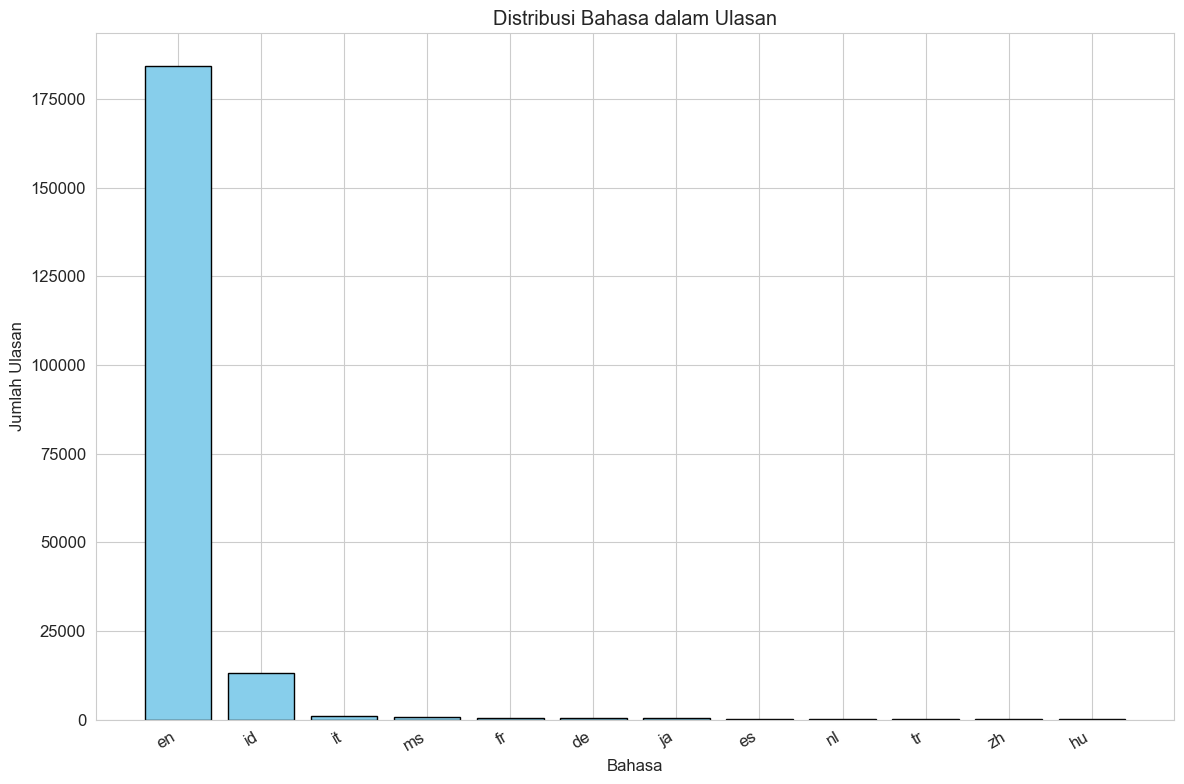

In [24]:
lang_counts = dfl["detected_language"].value_counts().sort_values(ascending=False).head(12)

# === Plot Bar Chart ===
plt.figure(figsize=(12,8))
plt.bar(lang_counts.index, lang_counts.values, color="skyblue", edgecolor="black")
plt.title("Distribusi Bahasa dalam Ulasan")
plt.xlabel("Bahasa")
plt.ylabel("Jumlah Ulasan")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


<Figure size 1200x700 with 0 Axes>

In [4]:
dft['location'].value_counts()

location
bali          39558
jakarta       31693
yogjakarta    30422
surabaya      25511
semarang      24612
malang        23694
medan         18810
batu          10852
Name: count, dtype: int64

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker # Import modul ticker

dft = pd.read_excel('outputs/combined_reviews.xlsx')

print("Memproses DataFrame 'dft'...")

# Menambah kolom 'year' dan 'review_length' dari kolom yang ada
airbnb_segments = ['private', 'entire']
dft['year'] = dft['date'].str[:4].astype(int)
# dft = dft[dft['segment'] != 'unknown']
dft['segment'] = dft['segment'].replace('unknown', 'private')
dft['review_length'] = dft['comment'].str.split().str.len()
dft['source'] = np.where(dft['segment'].isin(airbnb_segments), 'Airbnb', 'Agoda')
dft['rating'] = np.where(dft['source'] == 'Airbnb', dft['rating'] * 2, dft['rating'])

# Membuat kolom 'travel_purpose' dari kolom 'location'
kota_bisnis = ['jakarta', 'surabaya', 'medan', 'semarang']

def tentukan_tujuan(kota):
    if str(kota).lower() in kota_bisnis:
        return 'Bisnis'
    else:
        return 'Liburan'

dft['travel_purpose'] = dft['location'].apply(tentukan_tujuan)

print("DataFrame 'dft' siap untuk divisualisasikan.")

# --- 2. Visualisasi EDA ---
print("\nMembuat visualisasi...")
# Mengatur style plot
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 12

# Definisikan palet warna konsisten
main_color_1 = '#9AC4FD' # Hijau
main_color_2 = '#447DFC' # Biru
main_color_3 = '#2D5CF1' # Kuning/Orange
main_color_4 = '#223BB1' # Merah

accent_color_1 = '#A14DFD'
accent_color_2 = '#7711D2'
accent_color_3 = '#641AA9'
secondary_color_1 = '#44B8A7'
tertiary_color_1 = '#F09E0F'

line_pallete_segments = {'entire': main_color_1, 'private': tertiary_color_1, 'low': accent_color_1, 'high': secondary_color_1}
palette_segments = {'entire': main_color_1, 'private': main_color_3, 'low': accent_color_1, 'high': accent_color_2}
palette_purpose = {'Bisnis': main_color_1, 'Liburan': main_color_2}
palette_language = sns.color_palette("viridis", 12) # Untuk bahasa, bisa pakai palet dengan banyak warna


Memproses DataFrame 'dft'...
DataFrame 'dft' siap untuk divisualisasikan.

Membuat visualisasi...


Gambar '1_distribusi_rating_final.png' berhasil disimpan.
Gambar '2_tren_ulasan_per_tahun_final.png' berhasil disimpan.


C:\Users\kevin\AppData\Local\Temp\ipykernel_22652\321752331.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=purpose_counts.index, y=purpose_counts.values, palette=palette_purpose)
C:\Users\kevin\AppData\Local\Temp\ipykernel_22652\321752331.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_counts.index, y=segment_counts.values, palette=palette_segments, order=segment_counts.index)


Gambar '3a_ulasan_berdasarkan_tujuan_perjalanan_final.png' berhasil disimpan.
Gambar '3b_ulasan_berdasarkan_tipe_akomodasi_final.png' berhasil disimpan.
Gambar '4_distribusi_panjang_ulasan_final.png' berhasil disimpan.
Gambar '6_tren_rating_per_segmen_tahun_final.png' berhasil disimpan.
Gambar '7_tren_rating_per_tujuan_tahun_final.png' berhasil disimpan.


C:\Users\kevin\AppData\Local\Temp\ipykernel_22652\321752331.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=lang_counts.index, y=lang_counts.values, palette=palette_language, order=lang_counts.index)
C:\Users\kevin\AppData\Local\Temp\ipykernel_22652\321752331.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lang_counts.index, y=lang_counts.values, palette=palette_language, order=lang_counts.index)


Gambar '8_distribusi_bahasa_log_scale_final.png' berhasil disimpan.


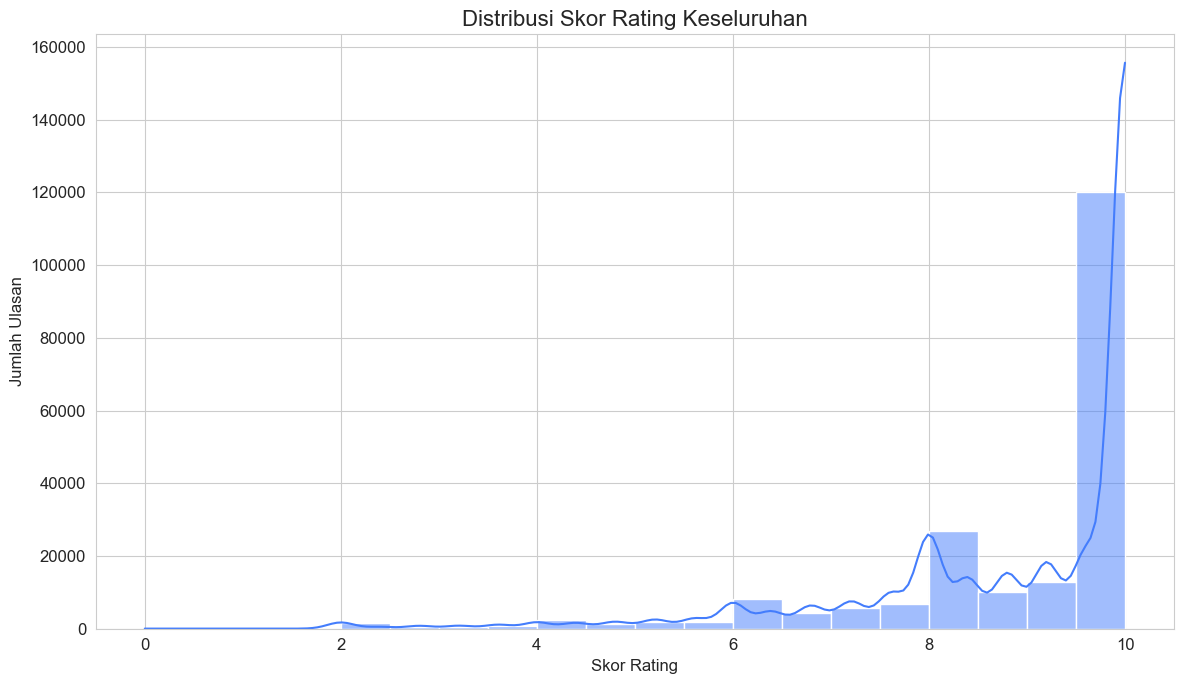

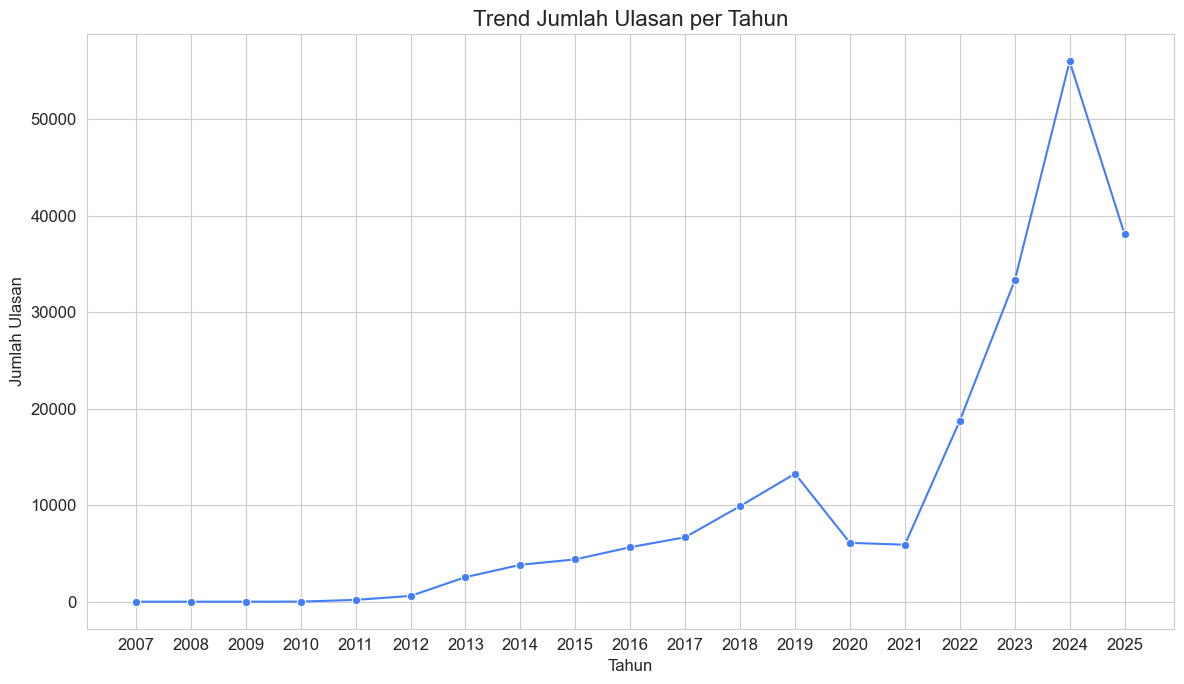

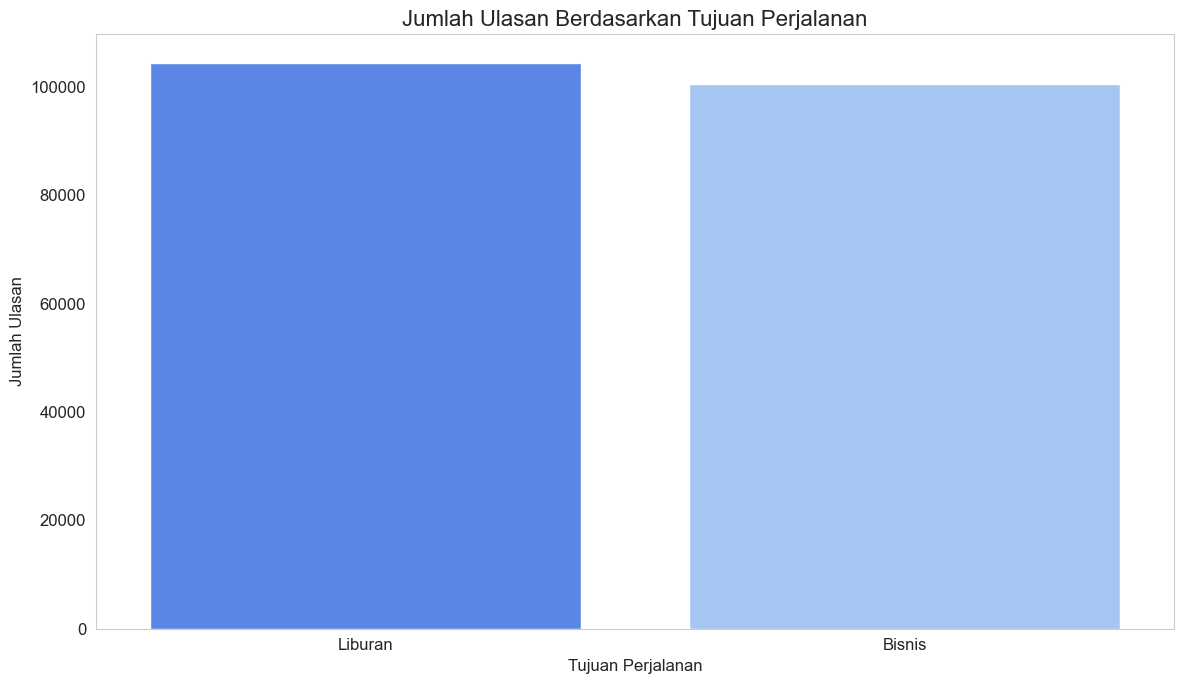

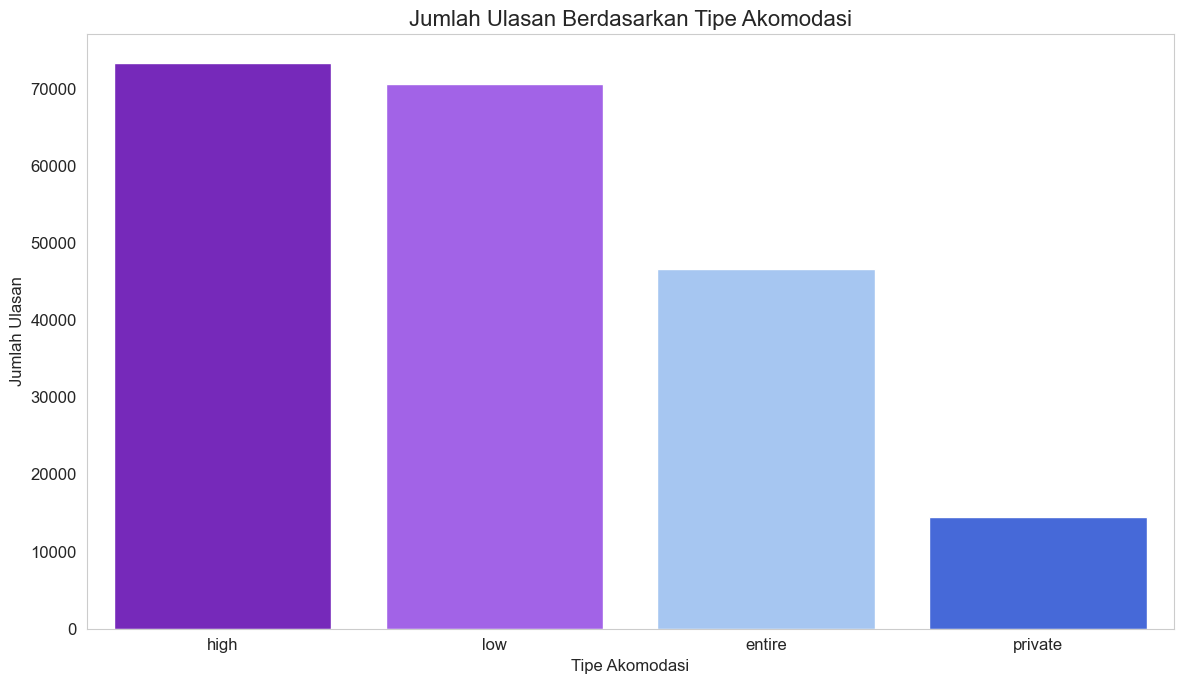

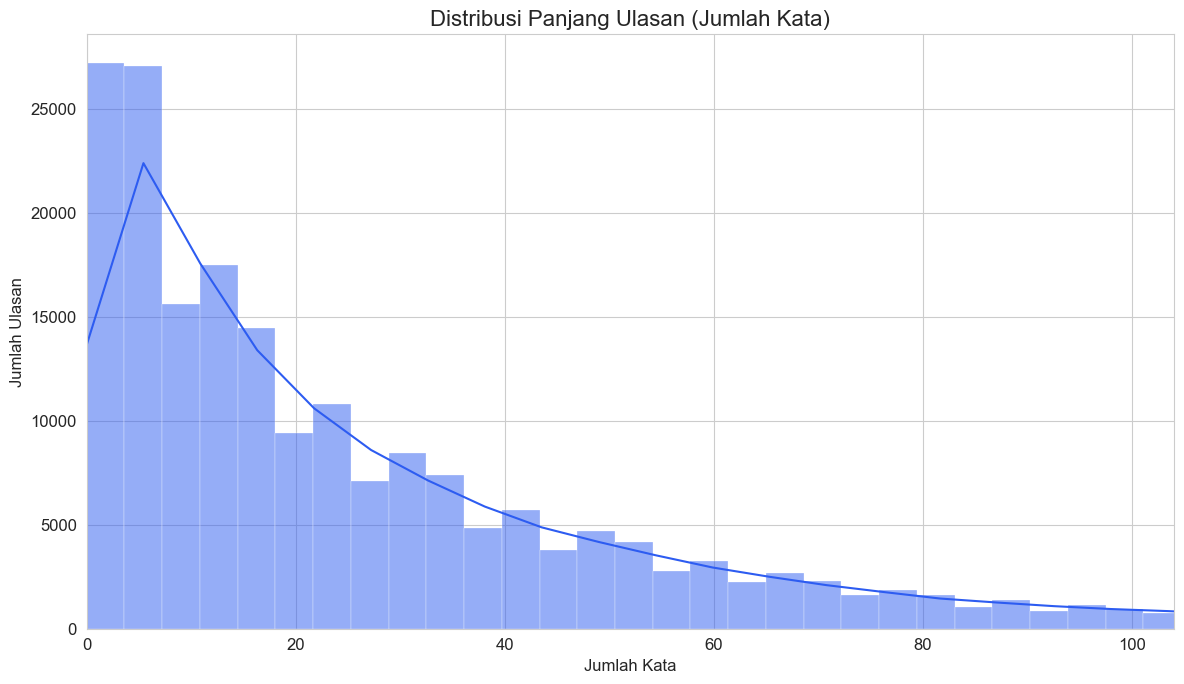

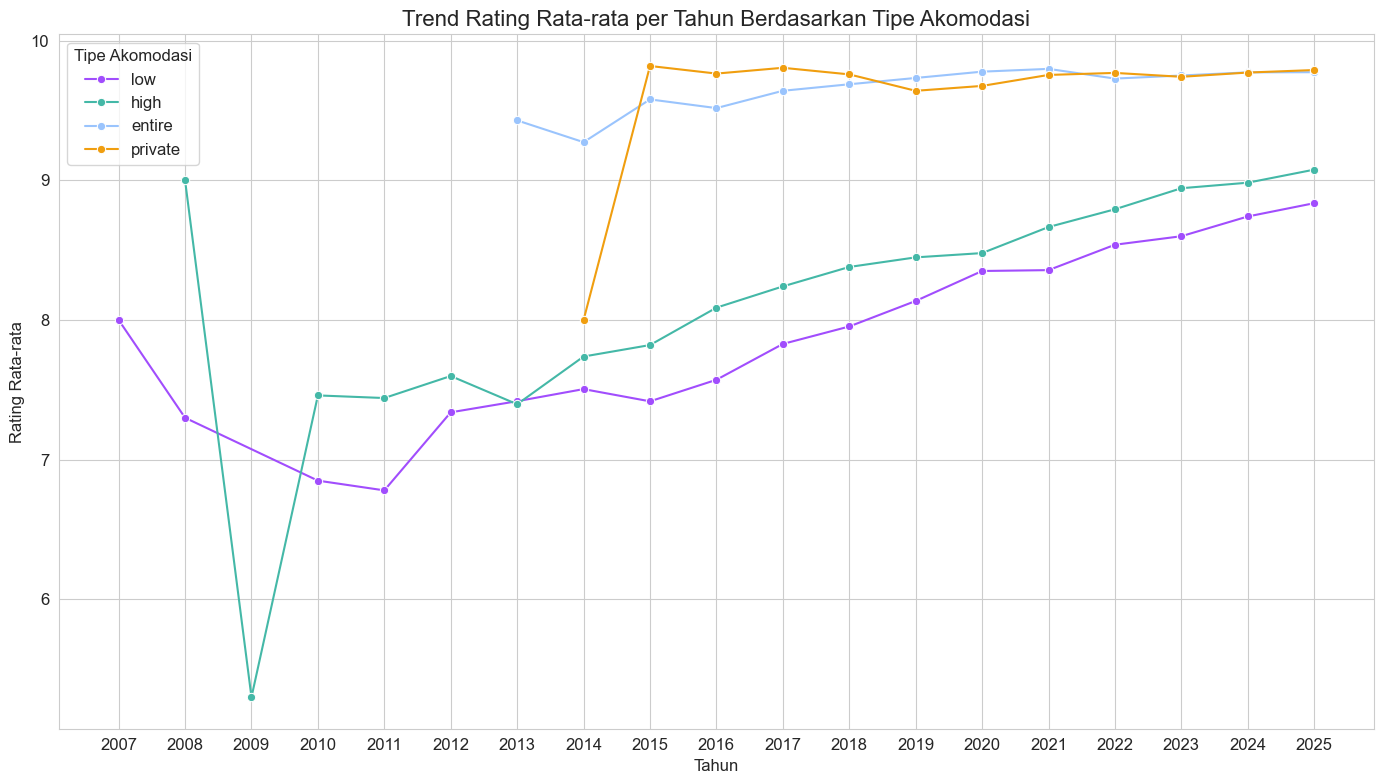

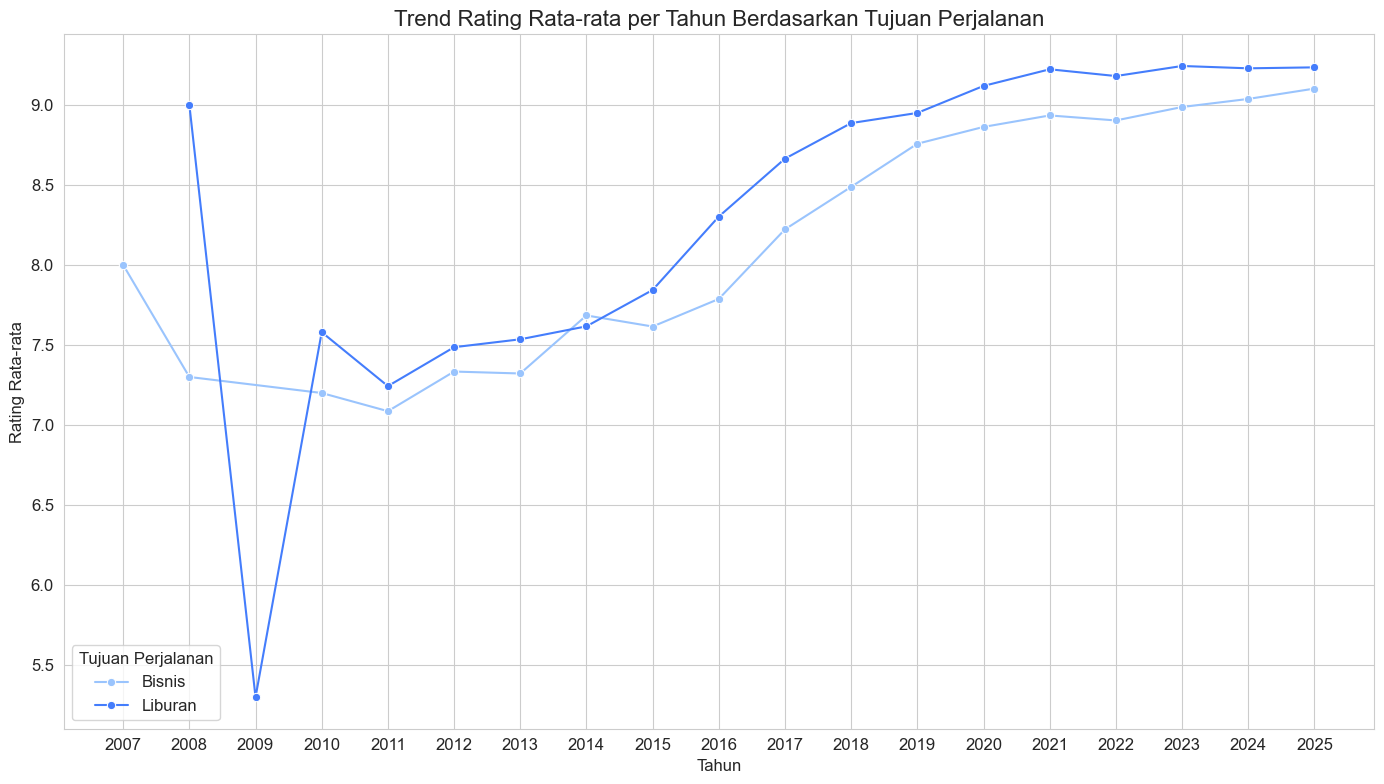

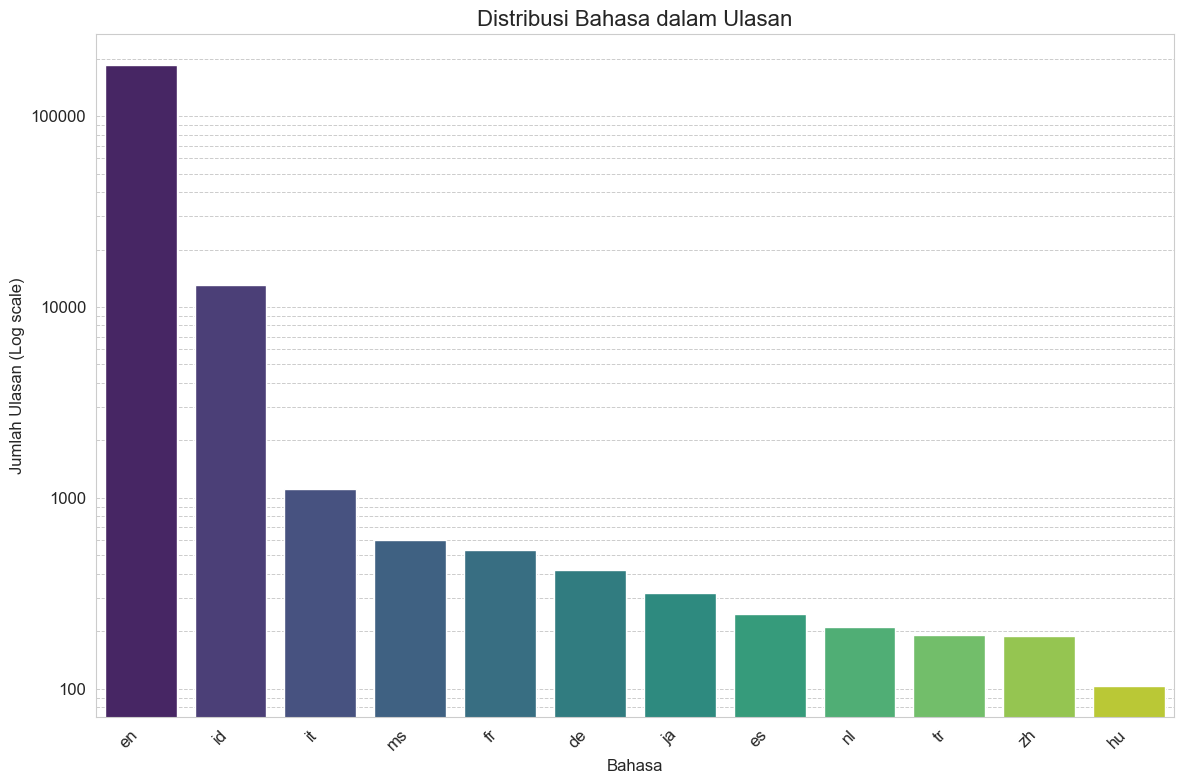

In [3]:
plt.figure()
sns.histplot(dft['rating'], kde=True, bins=20, color=main_color_2)
plt.title('Distribusi Skor Rating Keseluruhan', fontsize=16)
plt.xlabel('Skor Rating')
plt.ylabel('Jumlah Ulasan')
plt.tight_layout()
plt.savefig('eda/1_distribusi_rating_final.png')
print("Gambar '1_distribusi_rating_final.png' berhasil disimpan.")

# Plot 2: Jumlah Ulasan per Tahun
plt.figure()
reviews_per_year = dft['year'].value_counts().sort_index()
sns.lineplot(x=reviews_per_year.index, y=reviews_per_year.values, marker='o', color=main_color_2)
plt.title('Trend Jumlah Ulasan per Tahun', fontsize=16)
plt.xlabel('Tahun')
plt.ylabel('Jumlah Ulasan')
plt.xticks(reviews_per_year.index.astype(int))
plt.tight_layout()
plt.savefig('eda/2_tren_ulasan_per_tahun_final.png')
print("Gambar '2_tren_ulasan_per_tahun_final.png' berhasil disimpan.")

# Plot 3a: Jumlah Ulasan Berdasarkan Tujuan Perjalanan
plt.figure()
purpose_counts = dft['travel_purpose'].value_counts()
sns.barplot(x=purpose_counts.index, y=purpose_counts.values, palette=palette_purpose)
plt.title('Jumlah Ulasan Berdasarkan Tujuan Perjalanan', fontsize=16)
plt.xlabel('Tujuan Perjalanan')
plt.ylabel('Jumlah Ulasan')
plt.grid(axis='y') # Hanya gridline y
plt.tight_layout()
plt.savefig('eda/3a_ulasan_berdasarkan_tujuan_perjalanan_final.png')
print("Gambar '3a_ulasan_berdasarkan_tujuan_perjalanan_final.png' berhasil disimpan.")

# Plot 3b: Jumlah Ulasan Berdasarkan Tipe Akomodasi
plt.figure()
segment_counts = dft['segment'].value_counts()
sns.barplot(x=segment_counts.index, y=segment_counts.values, palette=palette_segments, order=segment_counts.index)
plt.title('Jumlah Ulasan Berdasarkan Tipe Akomodasi', fontsize=16)
plt.xlabel('Tipe Akomodasi')
plt.ylabel('Jumlah Ulasan')
plt.grid(axis='y') # Hanya gridline y
plt.tight_layout()
plt.savefig('eda/3b_ulasan_berdasarkan_tipe_akomodasi_final.png')
print("Gambar '3b_ulasan_berdasarkan_tipe_akomodasi_final.png' berhasil disimpan.")

# Plot 4: Distribusi Panjang Ulasan
plt.figure()
sns.histplot(dft['review_length'], kde=True, bins=300, color=main_color_3)
plt.title('Distribusi Panjang Ulasan (Jumlah Kata)', fontsize=16)
plt.xlabel('Jumlah Kata')
plt.ylabel('Jumlah Ulasan')
plt.xlim(0, dft['review_length'].quantile(0.95))
plt.tight_layout()
plt.savefig('eda/4_distribusi_panjang_ulasan_final.png')
print("Gambar '4_distribusi_panjang_ulasan_final.png' berhasil disimpan.")

# Plot 6: Tren Skor Rating Rata-rata per Tahun untuk Setiap Segmen Akomodasi
plt.figure(figsize=(14, 8))
avg_rating_trend_segment = dft.groupby(['year', 'segment'])['rating'].mean().reset_index()
sns.lineplot(data=avg_rating_trend_segment, x='year', y='rating', hue='segment', marker='o', palette=line_pallete_segments)
plt.title('Trend Rating Rata-rata per Tahun Berdasarkan Tipe Akomodasi', fontsize=16)
plt.xlabel('Tahun')
plt.ylabel('Rating Rata-rata')
plt.legend(title='Tipe Akomodasi')
plt.xticks(avg_rating_trend_segment['year'].unique().astype(int))
plt.tight_layout()
plt.savefig('eda/6_tren_rating_per_segmen_tahun_final.png')
print("Gambar '6_tren_rating_per_segmen_tahun_final.png' berhasil disimpan.")

# Plot 7: Tren Skor Rating Rata-rata per Tahun untuk Setiap Tujuan Perjalanan
plt.figure(figsize=(14, 8))
avg_rating_trend_purpose = dft.groupby(['year', 'travel_purpose'])['rating'].mean().reset_index()
sns.lineplot(data=avg_rating_trend_purpose, x='year', y='rating', hue='travel_purpose', marker='o', palette=palette_purpose)
plt.title('Trend Rating Rata-rata per Tahun Berdasarkan Tujuan Perjalanan', fontsize=16)
plt.xlabel('Tahun')
plt.ylabel('Rating Rata-rata')
plt.legend(title='Tujuan Perjalanan')
plt.xticks(avg_rating_trend_purpose['year'].unique().astype(int))
plt.tight_layout()
plt.savefig('eda/7_tren_rating_per_tujuan_tahun_final.png')
print("Gambar '7_tren_rating_per_tujuan_tahun_final.png' berhasil disimpan.")

# Visualisasi untuk data bahasa
dfl = pd.read_excel('outputs/translated_code.xlsx')
lang_counts = dfl["detected_language"].value_counts().sort_values(ascending=False).head(12)

# Plot Bar Chart Distribusi Bahasa
plt.figure(figsize=(12, 8))
ax = sns.barplot(x=lang_counts.index, y=lang_counts.values, palette=palette_language, order=lang_counts.index)
sns.barplot(x=lang_counts.index, y=lang_counts.values, palette=palette_language, order=lang_counts.index)
plt.yscale('log')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.title("Distribusi Bahasa dalam Ulasan", fontsize=16)
plt.xlabel("Bahasa")
plt.ylabel("Jumlah Ulasan (Log scale)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis='y', which='both', linestyle='--', linewidth=0.7) # Menyesuaikan grid untuk skala log
plt.tight_layout()
plt.savefig('eda/8_distribusi_bahasa_log_scale_final.png')
print("Gambar '8_distribusi_bahasa_log_scale_final.png' berhasil disimpan.")

plt.show()